# Data Exploartion

#### 1. Load data

In [1]:
import pandas as pd

df = pd.read_csv('./soccer_news_sample.csv')
df.head()

,title,text,url,publisher,dt
0,"""시즌 끝나지도 않았는데, 이비자 여행가서 DJ까지?""...리버풀 몰락 원인 지목한...",[스포티비뉴스=신인섭 기자] 맨체스터 유나이티드 레전드 폴 스콜스가 리버풀의 몰락의...,https://v.daum.net/v/XmOR2fHlvz,스포티비뉴스,5분 전
1,"레알 마드리드 내부 뒤흔든 불화설… 알론소의 여유 있는 정면돌파 “자연스러운 일, ...",[포포투=김호진] 사비 알론소 감독이 팀 내 불화설에 대해 입을 열었다. 영국 ‘스...,https://v.daum.net/v/KyUdQM3GRT,포포투,5분 전
2,"손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...",[OSEN=강필주 기자] '레비 시대'를 마감한 'NEW 토트넘'이 구단의 아이콘이...,https://v.daum.net/v/0EvouzlwS6,OSEN,21분 전
3,"배준호 2경기 연속 공격포인트…스토크시티, 찰턴에 3-0 완승",잉글랜드 챔피언십 스토크시티의 배준호가 시즌 두 번째 도움을 기록하며 팀의 완승을 ...,https://v.daum.net/v/xpW1YHAiRG,포모스,23분 전
4,"첼시, 10명 된 바르셀로나 3-0 격파…쿠쿠레야가 야말 완전 봉쇄",첼시가 유럽축구연맹 챔피언스리그(UCL) 리그 페이즈 5차전에서 스페인 강호 바르셀...,https://v.daum.net/v/p8CaK2YCJS,포모스,25분 전


#### 2. Natural Language Processing
Extract **meaningful** words from corpus!
(Remove stopwords, etc.)

In [2]:
from konlpy.tag import Okt

okt = Okt()

def get_words_ko(okt, text, stopwords=None):
    tagged = okt.pos(text, 
                     stem=True, 
                     norm=True)
    filtered = [w for w, pos in tagged if pos[0] == 'N']
    filtered = [w for w in filtered if len(w) > 1]  # Remove single-character words
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]

    return filtered

In [3]:
stopwords = ['제보', '카톡', '뉴스', '스포츠', '축구', '기자']

df['words'] = df['text'].apply(lambda x: get_words_ko(okt, x, stopwords=stopwords))

In [4]:
df.head()

,title,text,url,publisher,dt,words
0,"""시즌 끝나지도 않았는데, 이비자 여행가서 DJ까지?""...리버풀 몰락 원인 지목한...",[스포티비뉴스=신인섭 기자] 맨체스터 유나이티드 레전드 폴 스콜스가 리버풀의 몰락의...,https://v.daum.net/v/XmOR2fHlvz,스포티비뉴스,5분 전,"[스포, 티비, 신인섭, 맨체스터, 유나이티드, 레전드, 스콜스, 리버풀, 몰락, ..."
1,"레알 마드리드 내부 뒤흔든 불화설… 알론소의 여유 있는 정면돌파 “자연스러운 일, ...",[포포투=김호진] 사비 알론소 감독이 팀 내 불화설에 대해 입을 열었다. 영국 ‘스...,https://v.daum.net/v/KyUdQM3GRT,포포투,5분 전,"[포포투, 김호진, 사비, 알론소, 감독, 불화설, 대해, 영국, 바이블, 지난, ..."
2,"손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...",[OSEN=강필주 기자] '레비 시대'를 마감한 'NEW 토트넘'이 구단의 아이콘이...,https://v.daum.net/v/0EvouzlwS6,OSEN,21분 전,"[레비, 시대, 마감, 토트넘, 구단, 아이콘, 손흥민, 33, 귀환, 통해, 팬심..."
3,"배준호 2경기 연속 공격포인트…스토크시티, 찰턴에 3-0 완승",잉글랜드 챔피언십 스토크시티의 배준호가 시즌 두 번째 도움을 기록하며 팀의 완승을 ...,https://v.daum.net/v/xpW1YHAiRG,포모스,23분 전,"[잉글랜드, 챔피언십, 스토크시티, 배준호, 시즌, 도움, 기록, 완승, 배준호, ..."
4,"첼시, 10명 된 바르셀로나 3-0 격파…쿠쿠레야가 야말 완전 봉쇄",첼시가 유럽축구연맹 챔피언스리그(UCL) 리그 페이즈 5차전에서 스페인 강호 바르셀...,https://v.daum.net/v/p8CaK2YCJS,포모스,25분 전,"[첼시, 유럽, 연맹, 챔피언스리그, 리그, 페이, 스페인, 강호, 바르셀로나, 3..."


Q. How to check the distribution of News Lengths?

<Axes: title={'center': 'Distribution of News Lengths'}, xlabel='News Length', ylabel='Frequency'>

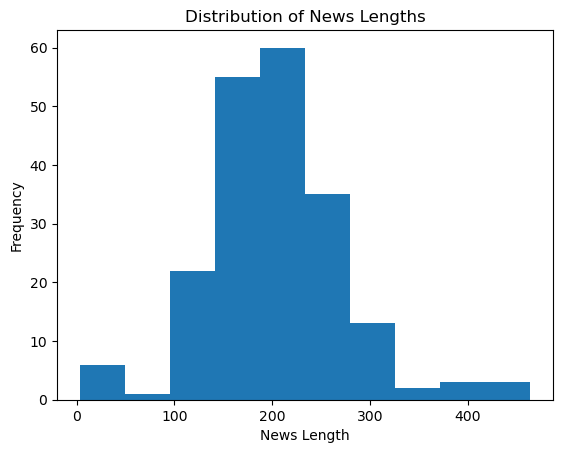

In [5]:
df['words'].apply(len).plot.hist(bins=10, 
                                 title='Distribution of News Lengths',
                                 xlabel='News Length')

In [6]:
df[df['words'].apply(len) < 50]

,title,text,url,publisher,dt,words
95,EL SALVADOR SOCCER,"epa12549199 Yamil Bukele, president of the gov...",https://v.daum.net/v/PBunC1DgZC,연합뉴스,2025.11.26 13:24,"[12549199, 2025-2029, 25, 2025]"
98,BRAZIL SOCCER,"epa12549150 The director of NR Sports, Neymar ...",https://v.daum.net/v/ux11C1DgGF,연합뉴스,2025.11.26 13:01,"[12549150, 25, 2025]"
99,BRAZIL SOCCER,epa12549154 Former Brazilian player Pepe react...,https://v.daum.net/v/9OsvcvLxXd,연합뉴스,2025.11.26 13:01,"[12549154, 25, 2025]"
100,BRAZIL SOCCER,epa12549152 An illuminated mural of Pele next ...,https://v.daum.net/v/GXlGrGjJXO,연합뉴스,2025.11.26 13:01,"[12549152, 25, 2025]"
101,BRAZIL SOCCER,"epa12549155 Flavia Arantes, Pele's daughter, s...",https://v.daum.net/v/9p4uWuCE5X,연합뉴스,2025.11.26 13:01,"[12549155, 25, 2025]"
105,BRAZIL SOCCER,epa12549143 Bruno Pinto (L) of Flamengo celebr...,https://v.daum.net/v/fZH16aKpHl,연합뉴스,2025.11.26 12:45,"[12549143, 25, 2025]"


#### 3. Draw Word Cloud

1. Without any preprocessing

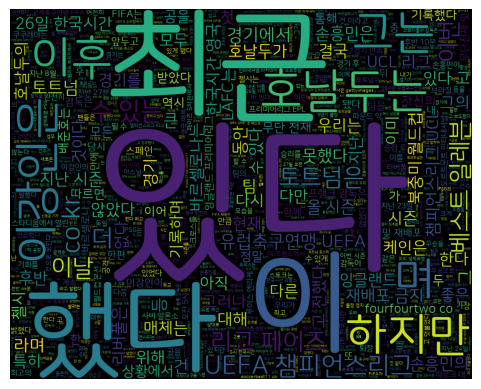

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


corpus = df['text']

text = ' '.join(corpus) # all text documents in one string
wc = WordCloud(font_path='NanumSquareRoundR.ttf', width=1000, height=800, max_words=1000).generate(text)
plt.imshow(wc)
plt.axis("off")
plt.show()

2. After applying NLP

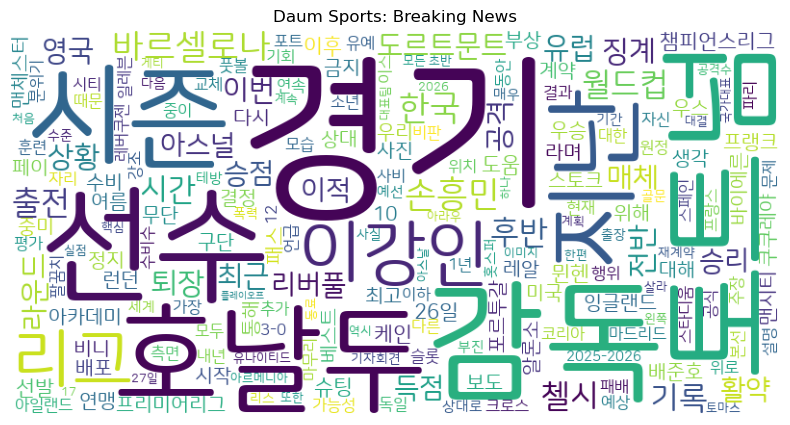

In [8]:
import itertools
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

def flatten_list(list_of_lists):
    return list(itertools.chain.from_iterable(list_of_lists))

def draw_wordcloud(words, title=None):
    word_freq = Counter(words)
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


words_all = flatten_list(df['words'])
draw_wordcloud(words_all, title='Daum Sports: Breaking News')